In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import requests
import re

import yfinance as yf

import gdp_mkt_cap_functions as funcs

In [2]:
crp_raw_data = pd.read_csv('country_risk_premiums.csv', index_col=0)
crp_raw_data = crp_raw_data.dropna(subset=['Country Risk Premium', 'Total Equity Risk Premium'])

In [7]:
# Build the translation CSV once.
translation_table = funcs.build_crp_country_translation_csv()

In [8]:
# After the translation file is saved, reuse it for annual GDP download.
gdp_table = funcs.download_worldbank_gdp_from_translation_csv()

In [3]:
gdp_table = pd.read_csv('annual_gdp_by_country.csv', index_col=0)

In [4]:
# Join expected GDP growth to the original CRP table.
crp_data = funcs.calculate_expected_gdp_growth_rate(
    crp_df=crp_raw_data,
    gdp_path="annual_gdp_by_country.csv",
    out_path="crp_data.csv",
    growth_years=10
)

# Ensure Country is available as a column for display.
if "Country" not in crp_data.columns:
    if crp_data.index.name == "Country":
        crp_data = crp_data.reset_index()
    elif len(crp_data) == len(crp_data):
        crp_data.insert(0, "Country", crp_data.index.to_numpy())

crp_data.dropna(subset=["expected_gdp_growth_rate_pct"], inplace=True)

# Build a country-indexed latest GDP series (nth(-1) keeps original row index, which breaks map).
latest_gdp = (
    gdp_table.sort_values(["country_name_in_crp", "year"])
    .dropna(subset=["annual_gdp_usd"])
    .groupby("country_name_in_crp")["annual_gdp_usd"]
    .last()
)

# Fix Country values (they were numeric row ids, not country names), then map latest GDP.
country_lookup = crp_raw_data.reset_index()["Country"]  # index -> country name

if pd.api.types.is_numeric_dtype(crp_data["Country"]):
    crp_data["Country"] = pd.to_numeric(crp_data["Country"], errors="coerce").map(country_lookup)

# Fallback: if any Country still missing, try rebuilding from the DataFrame index.
if crp_data["Country"].isna().any():
    idx_num = pd.to_numeric(crp_data.index, errors="coerce")
    valid = idx_num.notna()
    crp_data.loc[valid, "Country"] = idx_num[valid].astype(int).map(country_lookup)

crp_data["GDP_0"] = crp_data["Country"].astype(str).str.strip().map(latest_gdp)
crp_data['GDP_1'] = crp_data['GDP_0'] * (1 + crp_data['expected_gdp_growth_rate_pct']) 
crp_data[[
    "Country",
    "Region",
    "Country Risk Premium",
    "Total Equity Risk Premium",
    "expected_gdp_growth_rate_pct",
    "expected_gdp_growth_window_years",
    "expected_gdp_growth_start_year",
    "expected_gdp_growth_end_year", 
    "GDP_0",
    "GDP_1"
]].head()

,Country,Region,Country Risk Premium,Total Equity Risk Premium,expected_gdp_growth_rate_pct,expected_gdp_growth_window_years,expected_gdp_growth_start_year,expected_gdp_growth_end_year,GDP_0,GDP_1
1,Albania,Eastern Europe & Russia,0.044512,0.086512,0.109487,9.0,2016.0,2025.0,3.054019e+10,3.388395e+10
3,Angola,Africa,0.080442,0.122442,0.080685,9.0,2016.0,2025.0,1.221749e+11,1.320326e+11
4,Argentina,Central and South America,0.092806,0.134806,0.022825,9.0,2016.0,2025.0,6.830979e+11,6.986898e+11
5,Armenia,Eastern Europe & Russia,0.044512,0.086512,0.119992,9.0,2016.0,2025.0,2.924345e+10,3.275244e+10
6,Aruba,Caribbean,0.027202,0.069202,0.038635,9.0,2015.0,2024.0,4.167588e+09,4.328603e+09


In [5]:
risk_free_rate = 0.0425  # 4.25% risk-free rate assumption
crp_data['Cost of Equity'] = risk_free_rate + crp_data['Total Equity Risk Premium'] + crp_data['Country Risk Premium'] + crp_data['expected_gdp_growth_rate_pct']
crp_data['PV_of GDP'] = crp_data['GDP_1'] / (crp_data['Cost of Equity'] - crp_data['expected_gdp_growth_rate_pct'])

In [6]:
crp_data.to_csv("crp_data.csv", index=False)

In [7]:
market_cap_data = funcs.fetch_market_cap_data()

In [8]:
crp_data_renamed = crp_data[['Country', 'PV_of GDP']].copy()
crp_data_renamed = crp_data_renamed.rename(columns={'Country': 'country/company', 'PV_of GDP': 'PV_of_GDP/Mkt_Cap'})
market_cap_data_renamed = market_cap_data[['company', 'market_cap_usd']].rename(columns={'company': 'country/company', 'market_cap_usd': 'PV_of_GDP/Mkt_Cap'})
country_vs_company = pd.concat([crp_data_renamed, market_cap_data_renamed], ignore_index=True)
country_vs_company

,country/company,PV_of_GDP/Mkt_Cap
0,Albania,1.952693e+11
1,Angola,5.380662e+11
2,Argentina,2.586662e+12
3,Armenia,1.887486e+11
4,Aruba,3.116263e+10
...,...,...
135,TSMC,2.214002e+12
136,SpaceX,1.854149e+12
137,Broadcom,1.779525e+12
138,Saudi Aramco,1.681792e+12


In [9]:
country_vs_company.to_csv("country_vs_company.csv", index=False)

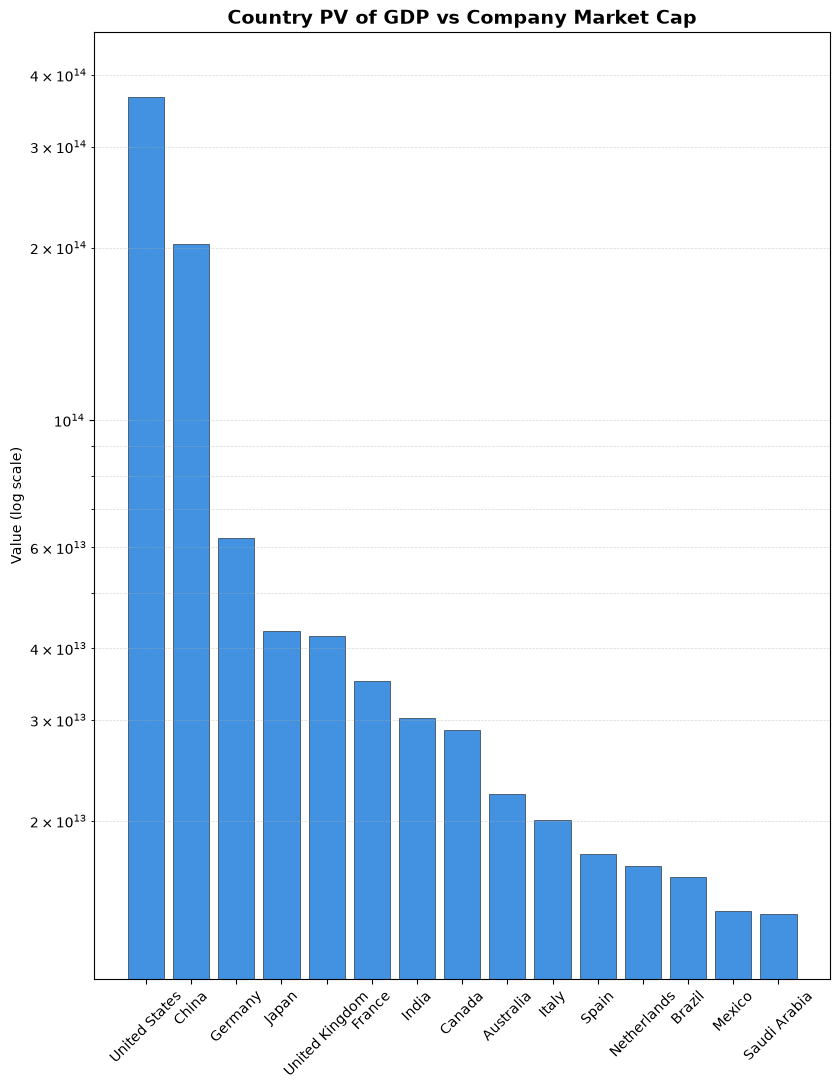

In [10]:
# Full comparison chart: every country and every company gets its own bar.
# This uses the complete dataset rather than truncating to 15 rows.
plot_df = country_vs_company.dropna(subset=['PV_of_GDP/Mkt_Cap']).copy()
plot_df['type'] = np.where(plot_df['country/company'].isin(market_cap_data['company'].tolist()), 'company', 'country')
plot_df = plot_df.sort_values('PV_of_GDP/Mkt_Cap', ascending=False).reset_index(drop=True)

colors = {'country': '#2E86DE', 'company': '#E76F51'}
fig, ax = plt.subplots(figsize=(8.5, 11))

ax.barh(
    plot_df['country/company'],
    plot_df['PV_of_GDP/Mkt_Cap'],
    color=[colors[t] for t in plot_df['type']],
    edgecolor='black',
    linewidth=0.2,
    alpha=0.9,
    height=0.8,
)

ax.set_xscale('log')
ax.set_xlabel('Value (log scale)', fontsize=10)
ax.set_title('Country PV of GDP vs Company Market Cap', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', which='both', linestyle='--', linewidth=0.4, alpha=0.45)
ax.invert_yaxis()

# Keep the labels readable while showing the full set of rows
plt.tight_layout()
plt.show()

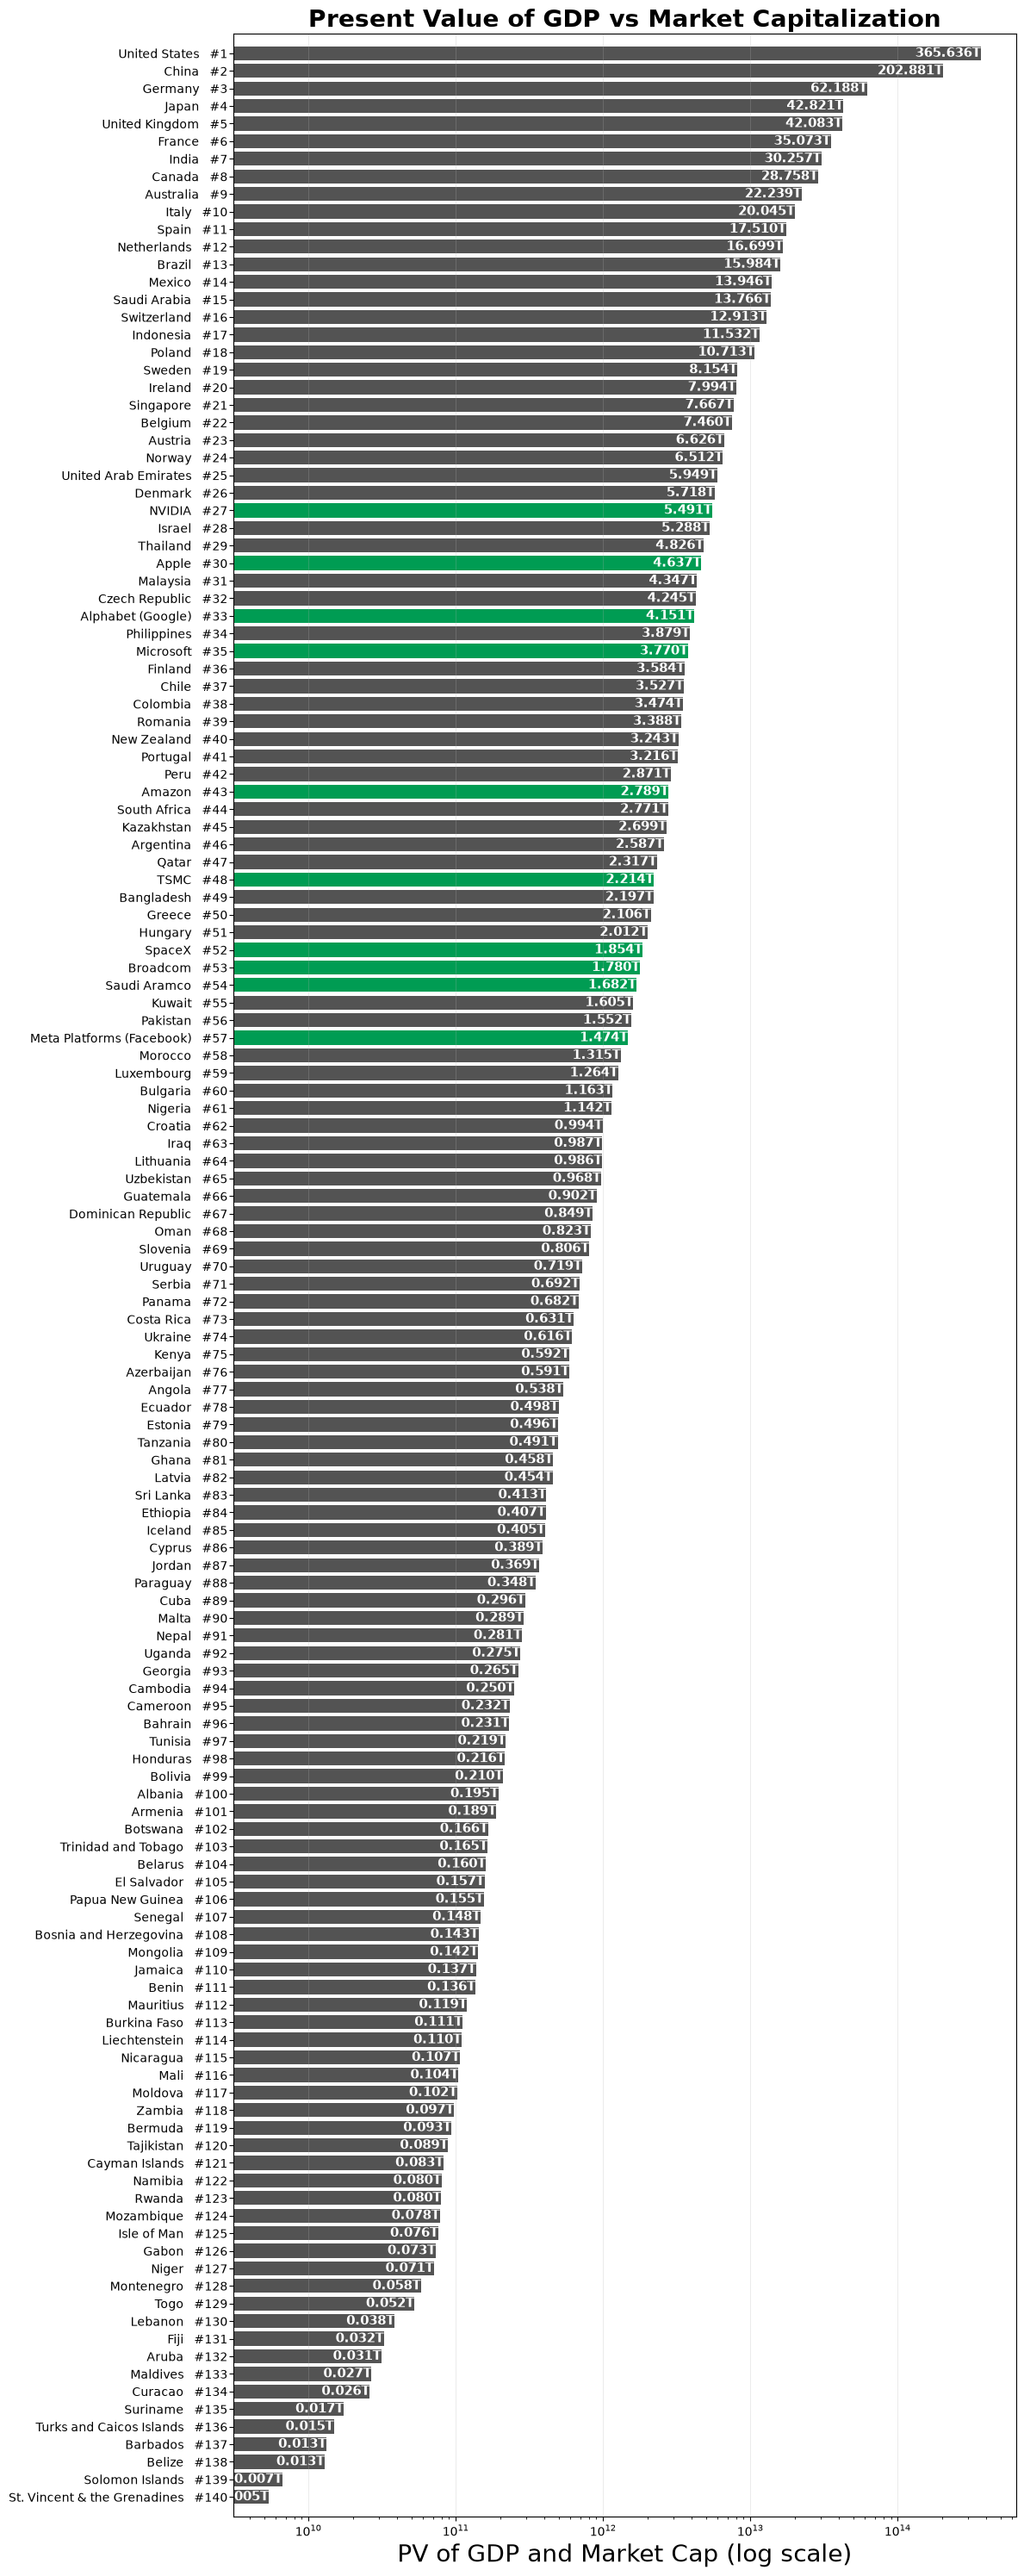

In [98]:
# Horizontal bar chart version for paper-friendly comparison.
plot_df = country_vs_company.dropna(subset=['PV_of_GDP/Mkt_Cap']).copy()
plot_df['type'] = np.where(
    plot_df['country/company'].isin(market_cap_data['company'].tolist()),
    'company',
    'country'
)

plot_df = plot_df.sort_values('PV_of_GDP/Mkt_Cap', ascending=False).reset_index(drop=True)
plot_df['rank'] = np.arange(1, len(plot_df) + 1)
plot_df['label'] = plot_df['country/company'] + '   #' + plot_df['rank'].astype(str)


colors = {'country': "#535353", 'company': "#009C53"}
fig, ax = plt.subplots(figsize=(12, 30))

bars = ax.barh(
    plot_df['label'],
    plot_df['PV_of_GDP/Mkt_Cap'],
    color=[colors[t] for t in plot_df['type']],
    edgecolor='black',
    linewidth=0,
    alpha=1,
    height=0.8
)

for bar, val in zip(bars, plot_df['PV_of_GDP/Mkt_Cap']/1e12):
    ax.text(
        val * 1e12 ,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.3f}T',
        va='center',
        ha='right',
        fontweight='bold',
        fontsize=11,
        color='white',
        clip_on=True
    )

ax.set_xscale('log')
ax.set_xlabel('PV of GDP and Market Cap (log scale)', fontsize=20)
ax.set_title('Present Value of GDP vs Market Capitalization', fontsize=20, fontweight='bold')
ax.grid(True, axis='x', which='major', linestyle='-', linewidth=0.4, alpha=0.45)
ax.tick_params(axis='y', labelsize=10, pad=1)
ax.invert_yaxis()
ax.margins(y=0.005)

# Keep labels readable while showing the full set of rows
plt.tight_layout()
plt.show()

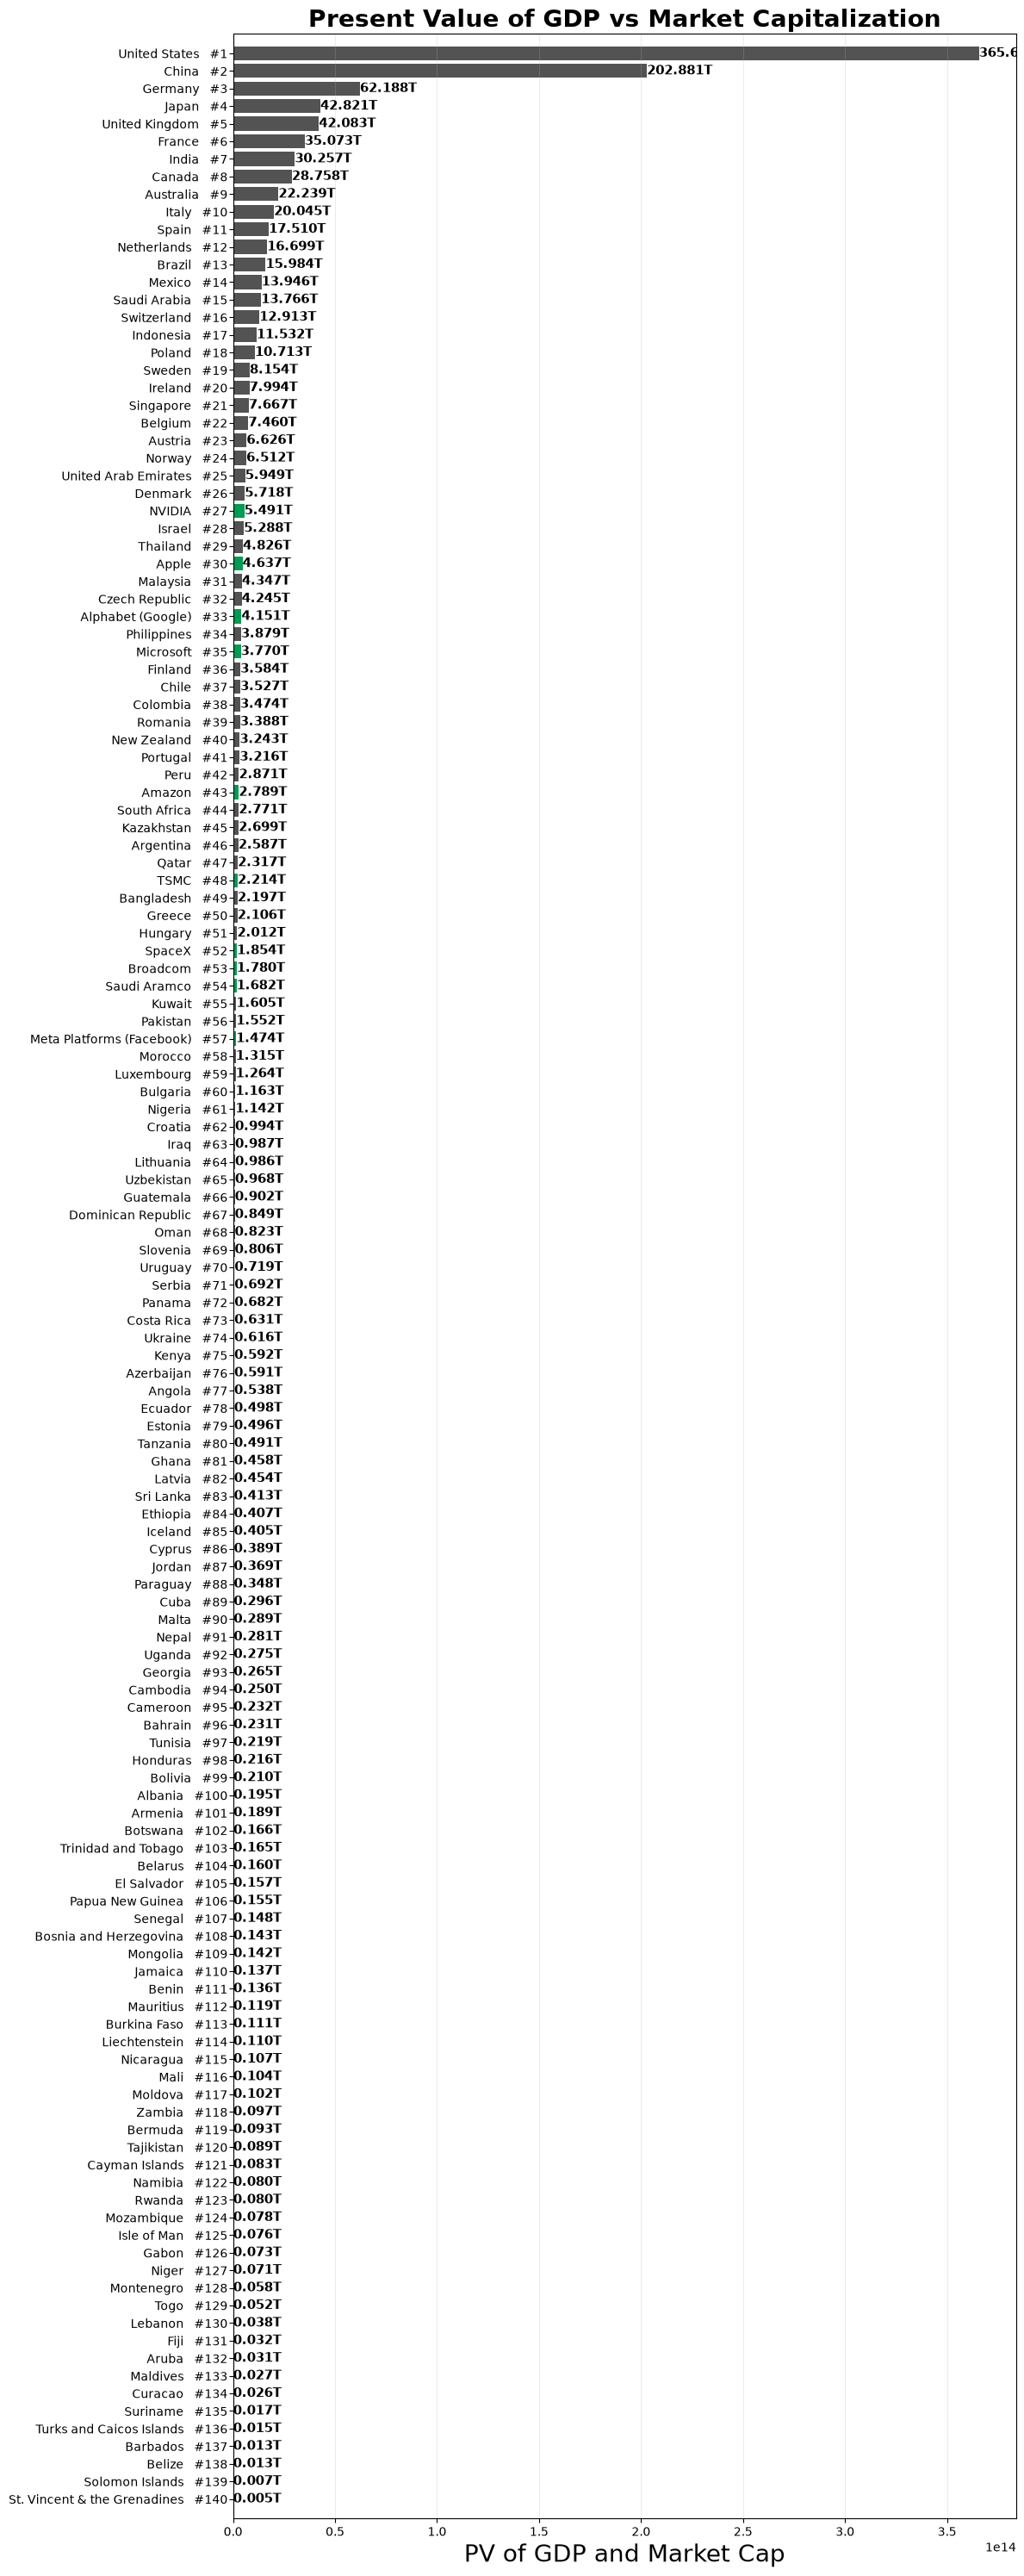

In [ ]:
# Horizontal bar chart version for paper-friendly comparison.
plot_df = country_vs_company.dropna(subset=['PV_of_GDP/Mkt_Cap']).copy()
plot_df['type'] = np.where(
    plot_df['country/company'].isin(market_cap_data['company'].tolist()),
    'company',
    'country'
)

plot_df = plot_df.sort_values('PV_of_GDP/Mkt_Cap', ascending=False).reset_index(drop=True)
plot_df['rank'] = np.arange(1, len(plot_df) + 1)
plot_df['label'] = plot_df['country/company'] + '   #' + plot_df['rank'].astype(str)


colors = {'country': "#535353", 'company': "#009C53"}
fig, ax = plt.subplots(figsize=(12, 30))

bars = ax.barh(
    plot_df['label'],
    plot_df['PV_of_GDP/Mkt_Cap'],
    color=[colors[t] for t in plot_df['type']],
    edgecolor='black',
    linewidth=0,
    alpha=1,
    height=0.8,
)

for bar, val in zip(bars, plot_df['PV_of_GDP/Mkt_Cap']/1e12):
    ax.text(
        val * 1e12 ,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.3f}T',
        va='center',
        ha='left',
        fontweight='bold',
        fontsize=11,
        color='black',
        clip_on=True
    )


ax.set_xlabel('PV of GDP and Market Cap', fontsize=20)
ax.set_title('Present Value of GDP vs Market Capitalization', fontsize=20, fontweight='bold')
ax.grid(True, axis='x', which='major', linestyle='-', linewidth=0.4, alpha=0.45 )
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:,.0f}T'))
ax.set_xscale('linear')

ax.tick_params(axis='y', labelsize=10, pad=1)
ax.invert_yaxis()
ax.margins(y=0.005)

# Keep labels readable while showing the full set of rows
plt.tight_layout()
plt.show()